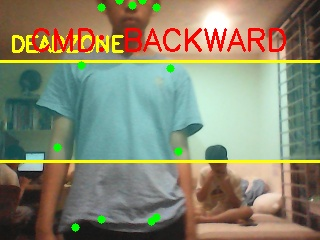

Done


In [23]:
import time
import importlib
import cv2
import numpy as np
from ugot import ugot
import pose_yolo

# Reload the pose control module so any edits to pose_yolo.py take effect
# without restarting the kernel.
importlib.reload(pose_yolo)
from pose_yolo import run_pose_control_inline

# Utilities for showing live camera frames directly inside the notebook
from IPython.display import display, clear_output, Image
from PIL import Image as Image2

# Create the robot controller object
got = ugot.UGOT()

# Connect to the UGOT robot using its IP address.
# Change this string if your robot is on a different IP.
got.initialize("192.168.137.177")

# Load the built-in computer vision models that will be used later in the notebook.
# You can load additional models here if needed — just add the model name to the list.
got.load_models(
    [
        "color_recognition",  # detects dominant colors
        "word_recognition",  # OCR: reads printed text
        "line_recognition",  # for line-following tasks
        "face_recognition",  # identifies registered faces by name
    ]
)

# Select the default line-tracking mode.
# 0 = single-line mode (follows one line at a time)
got.set_track_recognition_line(0)

# Open the camera stream so later functions can read live frames
got.open_camera()

try:
    run_pose_control_inline(
        robot_ip="192.168.137.177",
        forward_speed=5,
        backward_speed=5,
        turn_speed=10,
        camera_index=0,
        model_path="yolov8n-pose.pt",
        up_margin_factor=0.03,
        down_margin_factor=0.6,
        min_conf=0.3,
        enable_robot=False,  # <-- Robot is ENABLED: it will now move!
        debounce_frames=2,
        max_frames=None,
    )

except KeyboardInterrupt:
    print("Done")